In [2]:
import os
os.chdir("/home/philbou/projects/def-rfajber/philbou/FAWA")
import diagnostic_plot_helper as dps
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import FAWA_mod as fw
import cartopy.crs as ccrs
from skimage import measure
import matplotlib.colors as mcolors

base_cmap = plt.get_cmap('gist_ncar_r')
cmap_colors = base_cmap(np.arange(base_cmap.N))
cmap_colors[-1, -1] = 0  
transparent_cmap = mcolors.ListedColormap(cmap_colors)


R = 6371
lat_bounds = (0, 90)
lon_bounds = (0,360)#(-175 + 360, -30 + 360)
depth_bounds = (0, 1000)

In [5]:
x = xr.open_dataset("/home/philbou/scratch/isca_data/RT42_sst_1_bucket/run0360/moist_data_12h.nc")


In [6]:
x

<xarray.Dataset>
Dimensions:     (lon: 128, lat: 32, time: 60, pfull: 45, lat_interp: 100)
Coordinates:
  * lon         (lon) float64 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * lat         (lat) float64 1.395 4.186 6.977 9.767 ... 79.53 82.31 85.1 87.86
  * time        (time) object 0030-12-01 00:00:00 ... 0030-12-30 12:00:00
  * pfull       (pfull) float64 12.11 14.3 16.85 19.79 ... 951.3 974.8 992.6
  * lat_interp  (lat_interp) float64 1.395 2.269 3.142 ... 86.12 86.99 87.86
Data variables:
    P           (time, lat, lon) float64 ...
    E           (time, lat, lon) float64 ...
    q           (time, pfull, lat, lon) float32 ...
    qT          (time, pfull, lat, lon) float32 ...
    T           (time, pfull, lat, lon) float64 ...
    shape       (time, pfull, lat, lon) float32 ...
    precip_age  (time, lat, lon) float64 ...
    W           (time, lat, lon) float64 ...
    zonal_W     (time, lat) float64 ...
    T_V         (time, lat, lon) float64 ...
    CWV_A       (time, lat_interp, lon) float64 ...

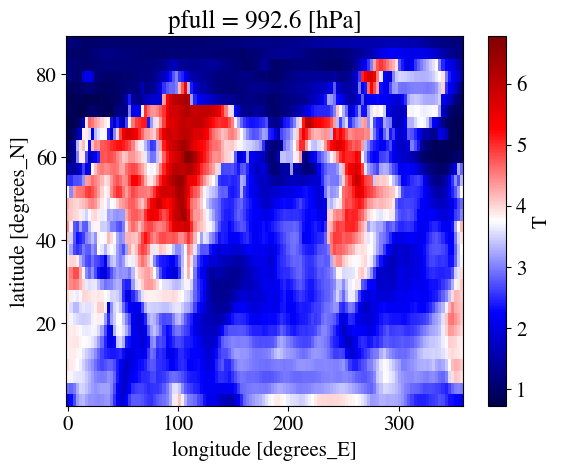

In [6]:
x.T.isel(pfull = -1).mean(dim = "time").plot(cmap = "seismic")

In [2]:
ds_CWV = xr.open_mfdataset("activity/zonal_W_daily.nc")
ds_age = xr.open_mfdataset("/home/philbou/projects/def-rfajber/philbou/saved_ds/RT42_sst_0_bucket/age.nc")
ds_data_6h_ = xr.open_mfdataset("/home/philbou/projects/def-rfajber/philbou/saved_ds/RT42_sst_0_bucket/data_6h.nc")
ds_dyn = xr.open_mfdataset("/home/philbou/projects/def-rfajber/philbou/saved_ds/RT42_sst_0_bucket/dynamics.nc")

W_base = ds_CWV.W
lat = ds_age.lat
lon = ds_age.lon
area = dps.get_area(ds_age)
eqlat = ds_CWV.eqlat

In [9]:
def select_region3D(ds, lat_range, lon_range, pfull_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1]),
        pfull=slice(pfull_range[0], pfull_range[1]),    
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region
def select_region2D(ds, lat_range, lon_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1])
    )
    return region

In [4]:
ds_data_6h = select_region3D(ds_data_6h_, lat_bounds, lon_bounds, depth_bounds)

area = dps.get_area(ds_data_6h)
lon = ds_data_6h.lon.values
lat = ds_data_6h.lat.values
bk = ds_dyn.bk.mean("time").values
ps = ds_data_6h.ps.mean("time").values
time = ds_data_6h.time
q = ds_data_6h.sphum.values
W = dps.vertical_int(q,bk,ps)

W_daily = xr.DataArray(
    W,
    dims=("time", "lat", "lon"),
    coords={
        "time": time,
        "lat": lat,
        "lon": lon
    },
    name="W"
)
lat_interp = np.linspace(eqlat[0],eqlat[-1],100)
W_base_interp = W_base.mean("time").interp(eqlat =lat_interp)
W_base_interp_tmp = W_base.isel(time = 0).interp(eqlat =lat_interp)

W_daily_interp = W_daily.interp(lat =lat_interp)

In [5]:
lat_interp = np.linspace(eqlat[0],eqlat[-1],100)
W_base_interp = W_base.mean("time").interp(eqlat =lat_interp)
W_base_interp_tmp = W_base.isel(time = 0).interp(eqlat =lat_interp)

W_daily_interp = W_daily.interp(lat =lat_interp)

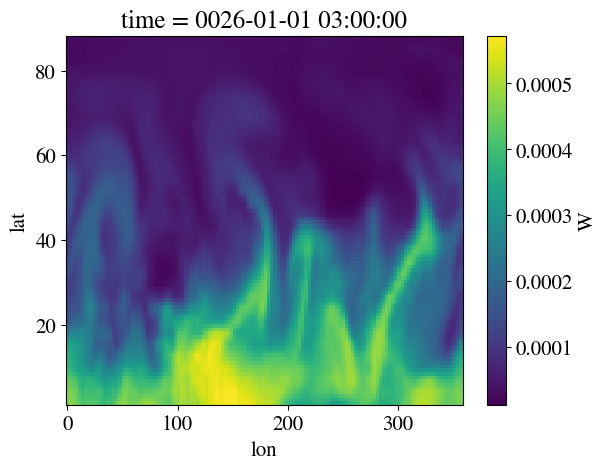

In [6]:
W_daily_interp.isel(time = 0).plot()

In [7]:
W_base_time = W_base_interp.values
W_2D_base = np.zeros((len(lat_interp),len(lon)))
for i in range(len(lat_interp)):
    W_2D_base[i,:] = np.ones(len(lon)) * W_base_time[i]


W_base_timetmp = W_base_interp_tmp.values
W_2D_basetmp = np.zeros((len(lat_interp),len(lon)))
for i in range(len(lat_interp)):
    W_2D_basetmp[i,:] = np.ones(len(lon)) * W_base_timetmp[i]


In [8]:
from datetime import datetime

In [10]:
ds_CWV = xr.open_mfdataset(f"/home/philbou/projects/def-rfajber/philbou/FAWA/activity/zonal_W_daily.nc")
fw.calc_save_activity(302,ds_CWV,out = True)

/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


loaded dataset
ready to calculate


100%|██████████| 120/120 [00:37<00:00,  3.18it/s]


'run0302.nc'

In [ ]:
dlon_tmp = (lon[1] - lon[0])
dlat_tmp = lat_interp[1] - lat_interp[0]

def compute_A_timestep(t,W,W_base_interp_np,lon,lat_interp,dlon_tmp,dlat_tmp):
    A = np.zeros((len(lat_interp),len(lon)))
    D = np.zeros_like(A)
    CWV_ = W.isel(time = t).values
    for lat_i in range(len(lat_interp)):
        for lon_i in range(len(lon)):
            A_minus = 0
            A_plus = 0
            phi_contour = lat_interp[lat_i]
            m_i = CWV_[lat_i,lon_i]
            idx = np.abs(W_base_interp_np - m_i).argmin()
            cur_phi = lat_interp[idx]
            cur_delta = phi_contour - cur_phi
            D[lat_i,lon_i] = cur_delta
            bot, top = min(cur_phi, phi_contour), max(cur_phi, phi_contour)
            bot_id = np.argmin(np.abs(lat_interp - bot))
            top_id = np.argmin(np.abs(lat_interp - top))
            col_sum = np.sum(CWV_[bot_id:top_id, lon_i] * R**2 * np.cos(np.deg2rad(lat_interp[bot_id:top_id])) * dlon_tmp * dlat_tmp)
            if cur_delta > 0:
                A_plus += col_sum
            elif cur_delta < 0:
                A_minus += col_sum
            
            A[lat_i,lon_i]+= (A_plus - A_minus) / (2*np.pi * R * np.cos(np.deg2rad(phi_contour)))
    return A
t=0
t0 = datetime.now()
A = compute_A_timestep(t,W_daily_interp,W_base_interp.values,lon,lat_interp,dlon_tmp,dlat_tmp)
t1 = datetime.now()
print(t1-t0)

0:00:00.329160


In [ ]:

P = ds_data_6h.precipitation.isel(time = t).values
land_mask_name = "era_land_t42.nc"
lm_path = "/home/philbou/Isca/exp/test_cases/wv_age/input/"+land_mask_name
ds_landmask_ = xr.open_dataset(lm_path) 
ds_landmask = select_region2D(ds_landmask_, lat_bounds, lon_bounds)
land_mask = ds_landmask.land_mask.values

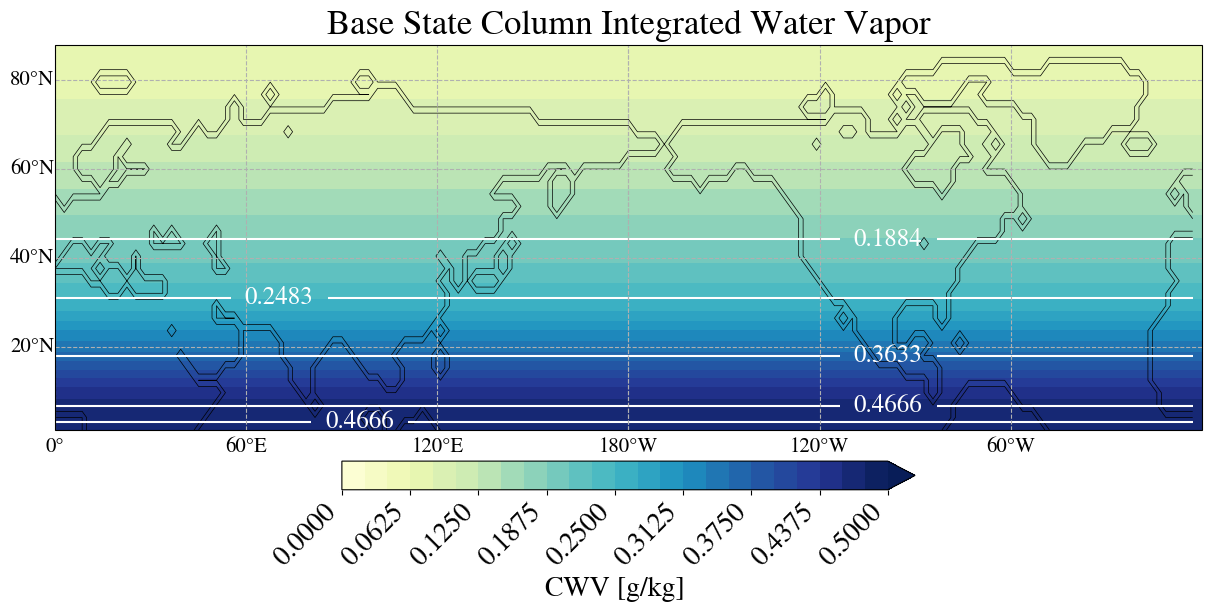

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, 
                            subplot_kw={'projection': ccrs.PlateCarree(central_longitude = 180)},figsize = (12,6),constrained_layout=True)
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

gl = ax.gridlines(draw_labels=True, linestyle='--')
ax.set_aspect('auto')
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
cb = dps.plot_2d(1e3 * W_2D_base,lat_interp,lon,ax,"YlGnBu",level_space=np.linspace(0,0.5,25),land_mask = land_mask,land_bool=True,lat_mask = lat,proj =  ccrs.PlateCarree(),extend = "max")
#cb = plt.contourf(lon,lat_interp,A,levels = np.linspace(-25,25,25),cmap = "coolwarm",extend = "max",transform = ccrs.PlateCarree())
#plt.colorbar(cb,shrink=0.5,orientation='horizontal',pad=0.01)
cb.set_label("CWV [g/kg]",fontsize = 20)
cb = plt.contour(lon,lat_interp,1e3 * W_2D_base,levels = 1e3*np.sort(W_base_time)[-50::15],colors = "w",transform = ccrs.PlateCarree())
plt.clabel(cb, inline=True, fontsize=18)
ax.set_title("Base State Column Integrated Water Vapor",fontsize = 25,pad = 8)
fig.savefig("basestate.png",dpi = 400)

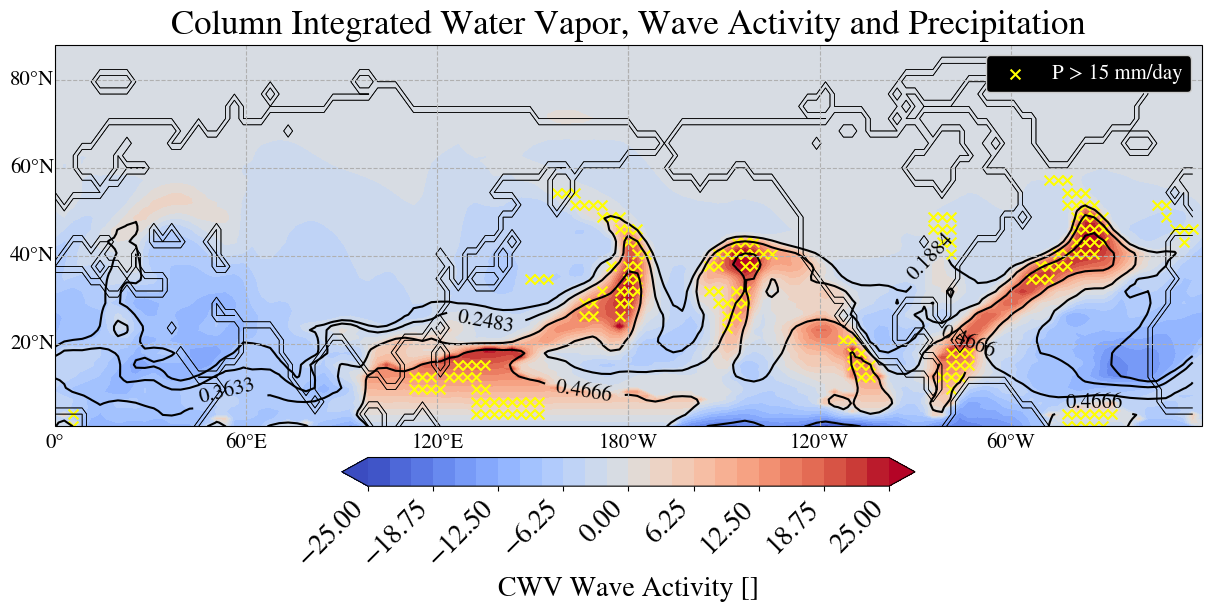

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, 
                            subplot_kw={'projection': ccrs.PlateCarree(central_longitude = 180)},figsize = (12,6),constrained_layout=True)

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl = ax.gridlines(draw_labels=True, linestyle='--')
ax.set_aspect('auto')
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
cb = dps.plot_2d(A,lat_interp,lon,ax,"coolwarm",level_space=np.linspace(-25,25,25),land_mask = land_mask,land_bool=True,lat_mask = lat,proj =  ccrs.PlateCarree(),extend = "both")
#cb = plt.contourf(lon,lat_interp,A,levels = np.linspace(-25,25,25),cmap = "coolwarm",extend = "max",transform = ccrs.PlateCarree())
#plt.colorbar(cb,shrink=0.5,orientation='horizontal',pad=0.01)
cb.set_label("CWV Wave Activity []",fontsize = 20)

# Create 2D coordinate arrays
Lon, Lat = np.meshgrid(lon, lat)

# Mask where P <= 15
mask =(84600* P) > 15


# Plot X's
ax.scatter(
    Lon[mask],
    Lat[mask],
    marker='x',
    s=50,
    color='yellow',transform = ccrs.PlateCarree(),label = "P > 15 mm/day"
)
CWV_ = W_daily_interp.isel(time = t).values
cb = plt.contour(lon,lat_interp,1e3 * CWV_,levels = 1e3*np.sort(W_base_time)[-50::15],colors = "black",transform = ccrs.PlateCarree())
plt.clabel(cb, inline=True, fontsize=15)

ax.contour(lon, lat, land_mask,
                colors="black",levels = 1,linewidths=0.5,transform = ccrs.PlateCarree())

ax.set_title("Column Integrated Water Vapor, Wave Activity and Precipitation",fontsize = 25,pad = 8)
ax.legend(framealpha = 1,fontsize = 15,facecolor = "black",labelcolor = "w")
fig.savefig(f"FAWA_sample_{t}.png",dpi = 400)

In [ ]:
latb = ds_age.latb
lonb = ds_age.lonb

latbf = np.linspace(latb[0],latb[-1],100*len(latb))
lonbf = np.linspace(lonb[0],lonb[-1],100*len(lonb))
da = xr.DataArray(
    W_2D_base,
    dims=("lat", "lon"),
    coords={
        "lat": lat,
        "lon": lon
    },
    name="W_2D_base"
)

ValueError: conflicting sizes for dimension 'lat': length 100 on the data but length 32 on coordinate 'lat'

In [ ]:
da_interp = da.interp(
    lat=latbf,
    lon=lonbf)

In [ ]:
da_interp.values.shape

(6500, 12900)

In [ ]:
intrusion_value = W_base_time[2]
intrusion_region = 40 * np.sin(np.pi * lon/360)

W_test = W_2D_base.copy()


In [ ]:
W_test[14:18,62:66] = intrusion_value
W_test[16,64] = intrusion_value*2

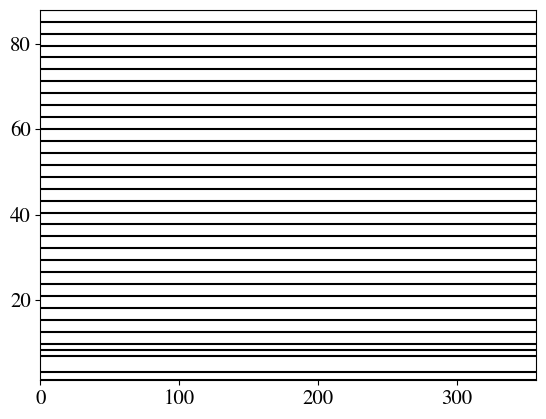

In [ ]:
cs = plt.contour(lon,lat,W_2D_base,levels = np.sort(W_base_time),colors = "black")

contour_list_plt = []
for level, collection in zip(cs.levels, cs.collections):
    paths = collection.get_paths()
    for path in collection.get_paths():
        cur = paths[0].vertices.transpose()
        lon_vals = cur[0,:]
        lat_vals = cur[1,:]
        contour_list_plt.append({"lon" : lon_vals, "lat" : lat_vals})

<a list of 45 text.Text objects>

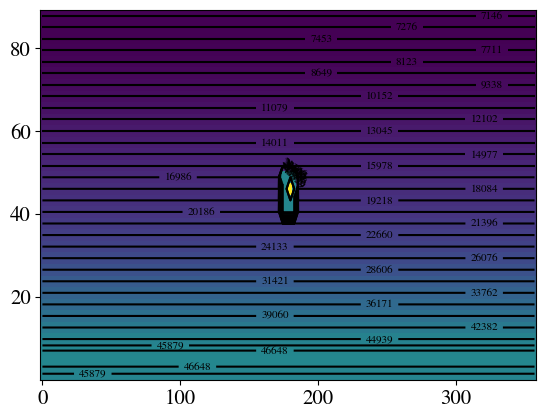

In [ ]:
plt.pcolormesh(lon,lat,W_test)
cb = plt.contour(lon,lat,W_test,levels = np.sort(W_base_time),colors = "black")
plt.clabel(cb, inline=True, fontsize=8)
#plt.ylim(30,60)
#plt.xlim(150,225)

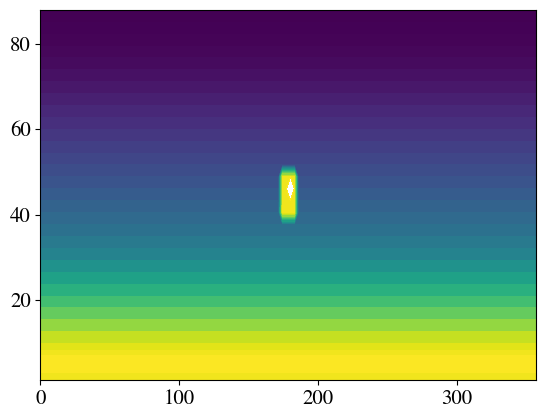

In [ ]:
plt.contourf(lon,lat,W_test,levels = np.sort(W_base_time))

In [ ]:
contour_list_ski = []

for M in W_base_time:
    contours = measure.find_contours(W_2D_base, level=M)
    for tmp1 in contours:
        tmp = tmp1.transpose()
        lat_ids = np.array(tmp[0], dtype = np.int32)
        lon_ids =  np.array(tmp[1], dtype = np.int32)
        lat_c = lat[lat_ids]
        lon_c = lon[lon_ids]
        contour_list_ski.append({"lon" : lon_c, "lat" : lat_c})

In [ ]:
contour_list_plt[-1]["lat"] #==contour_list_plt[0]["lon"]

array([3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792249,
       3.10792249, 3.10792249, 3.10792249, 3.10792249, 3.10792

(-1.0, 21.0)

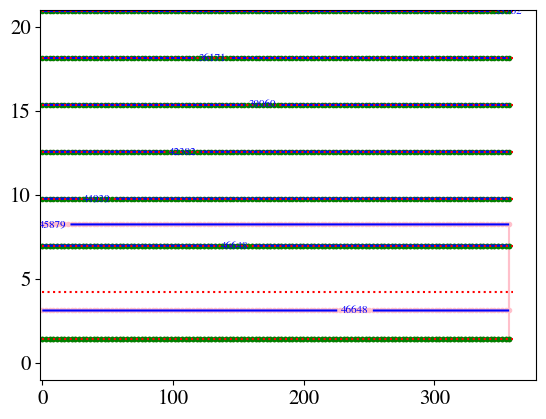

In [ ]:


for c in contour_list_plt:
    plt.plot(c["lon"], c["lat"],color = "pink",marker = ".")

for c in contour_list_ski:
    plt.plot(c["lon"], c["lat"],color = "green",marker = ".")

cb = plt.contour(lonbf,latbf,da_interp.values,levels = np.sort(W_base_time),colors = "blue")
plt.clabel(cb, inline=True, fontsize=8)

for eql in W_base.eqlat.values:
    plt.hlines(eql,0,360,color = "r",alpha = 1,linestyle = "dotted")


plt.ylim(-1,21)

In [ ]:
for seg in cb.allsegs:
    print(seg)

[]
[array([[3.45250480e+02, 8.50968229e+01],
       [3.45225272e+02, 8.50968229e+01],
       [3.45197363e+02, 8.50968229e+01],
       ...,
       [7.29344329e-02, 8.50968229e+01],
       [4.50252927e-02, 8.50968229e+01],
       [1.71161524e-02, 8.50968229e+01]])]
[array([[357.17038385,  82.31550377],
       [357.14247471,  82.31550377],
       [357.11456557,  82.31550377],
       ...,
       [132.75298715,  82.31550377],
       [132.72507801,  82.31550377],
       [132.69986975,  82.31550377]]), array([[1.09474063e+02, 8.23155038e+01],
       [1.09448855e+02, 8.23155038e+01],
       [1.09420946e+02, 8.23155038e+01],
       ...,
       [7.29344329e-02, 8.23155038e+01],
       [4.50252927e-02, 8.23155038e+01],
       [1.71161524e-02, 8.23155038e+01]])]
[array([[357.17038385,  79.52728245],
       [357.14247471,  79.52728245],
       [357.11456557,  79.52728245],
       ...,
       [110.64894808,  79.52728245],
       [110.62103894,  79.52728245],
       [110.59583068,  79.52728245]]), ar

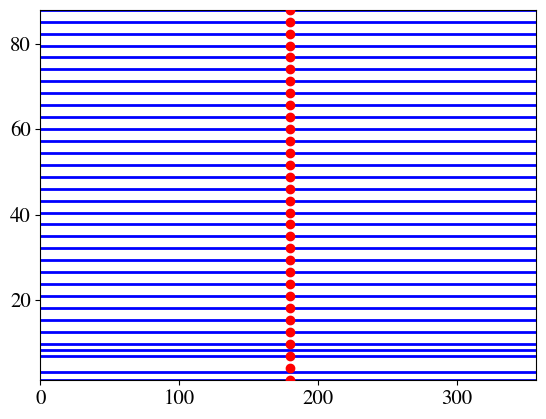

In [ ]:
plt.contour(lon, eqlat, W_2D_base, levels=np.sort(W_base_time), colors="blue", linewidths=2)
plt.scatter([180]*len(eqlat), eqlat, color="red", zorder=3)

(0.0, 20.0)

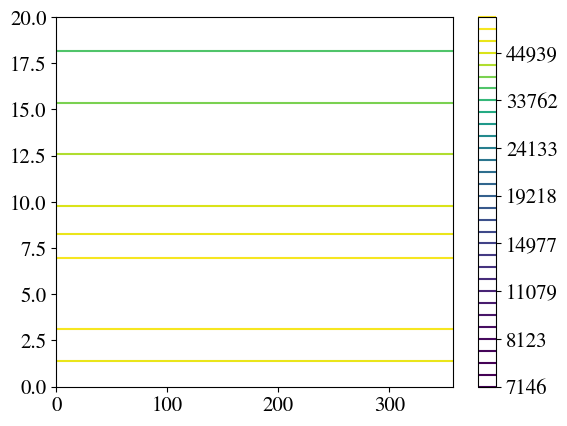

In [ ]:
cb = plt.contour(lon,lat,W_2D_base,levels = np.sort(W_base_time))
plt.colorbar(cb)

plt.ylim(0,20)



In [ ]:
cb = plt.contourf(lon,lat,1e3 * A,levels = np.linspace(-0.2,0.2,25), cmap = "seismic")
plt.colorbar(cb)

NameError: name 'A' is not defined